In [1]:
import mne
print(mne.__version__)

1.13.2


Using default location ~/mne_data for sample...
Creating C:\Users\Shriya\mne_data
Fetching 1 file for the sample dataset ...


  0%|                                              | 0.00/1.65G [00:00<?, ?B/s]

Untarring contents of 'C:\Users\Shriya\mne_data\MNE-sample-data-processed.tar.gz' to 'C:\Users\Shriya\mne_data'


Attempting to create new mne-python configuration file:
C:\Users\Shriya\.mne\mne-python.json
Could not read the C:\Users\Shriya\.mne\mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)
Download complete in 11m37s (1576.2 MB)
Opening raw data file C:\Users\Shriya\mne_data\MNE-sample-data\MEG\sample\sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.
Reading 0 ... 166799  =      0.000 ...   277.714 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Using matplotlib as 2D backend.
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


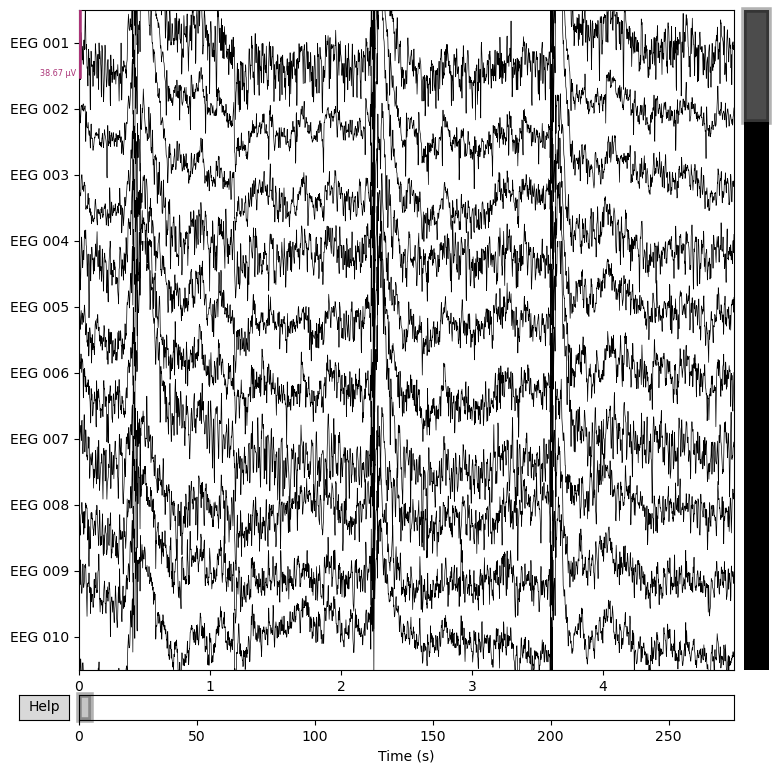

In [2]:
import matplotlib.pyplot as plt

# 1. Sample data
data_path = mne.datasets.sample.data_path()
raw_fname = data_path / "MEG" / "sample" / "sample_audvis_raw.fif"
raw = mne.io.read_raw_fif(raw_fname, preload=True)

# 2. EEG (Brain Waves) 
raw.pick_types(meg=False, eeg=True, eog=False)

# 3. To show graph within notebook
%matplotlib inline

# 4. Plotting Waves
raw.plot(duration=5, n_channels=10, scalings="auto")
plt.show()


Opening raw data file C:\Users\Shriya\mne_data\MNE-sample-data\MEG\sample\sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.
Reading 0 ... 166799  =      0.000 ...   277.714 secs...
Finding events on: STI 014
320 events found on stim channel STI 014
Event IDs: [ 1  2  3  4  5 32]
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Not setting metadata
72 matching events found
Setting baseline interval to [-0.19979521315838786, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 72 events and 421 original time points ...
0 bad epochs dropped


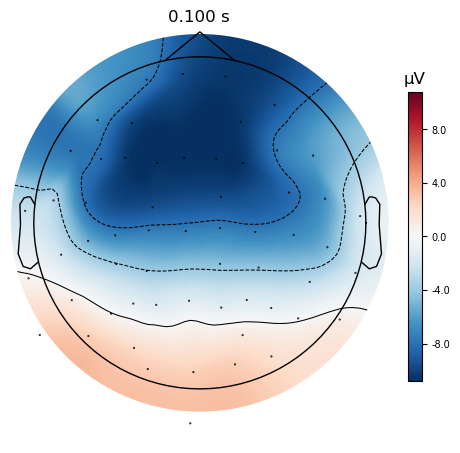

In [4]:
import numpy as np

# 1. Reload the raw data fresh so all channels are restored
data_path = mne.datasets.sample.data_path()
raw_fname = data_path / "MEG" / "sample" / "sample_audvis_raw.fif"
raw_fresh = mne.io.read_raw_fif(raw_fname, preload=True)

# 2. Find events using the stimulus channel 'STI 014' from the fresh data
events = mne.find_events(raw_fresh, stim_channel='STI 014')

# Define our auditory left-ear event dictionary
event_dict = {'auditory/left': 1}

# 3. Keep ONLY EEG and STIM channels this time (so we don't lose the trigger)
raw_fresh.pick_types(meg=False, eeg=True, stim=True, eog=False)

# 4. Segment the data into epochs around the auditory events
epochs = mne.epochs.Epochs(raw_fresh, events, event_id=event_dict, tmin=-0.2, tmax=0.5, preload=True)

# 5. Compute the average Evoked response to clean up background brain noise
evoked = epochs.average()

# 6. Ensure plots render inside the notebook
%matplotlib inline

# 7. Plot the 2D Brain Topomap at 100ms (0.1s) post-stimulus
evoked.plot_topomap(times=[0.1], ch_type='eeg', size=3)
plt.show()


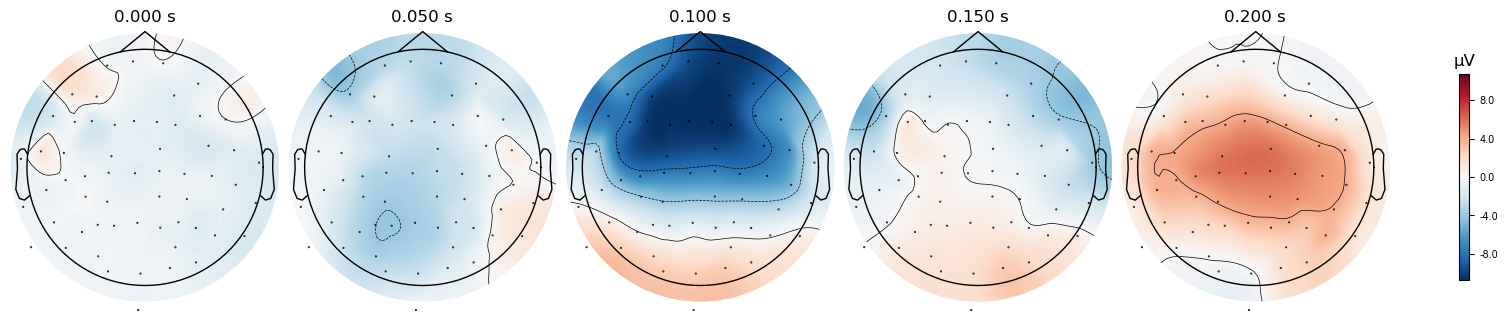

In [5]:
# Shows brain state in different time interval
times = [0.0, 0.05, 0.1, 0.15, 0.2]
evoked.plot_topomap(times=times, ch_type='eeg', ncols=5, size=2)
plt.show()


Effective window size : 3.410 (s)
Plotting power spectral density (dB=True).


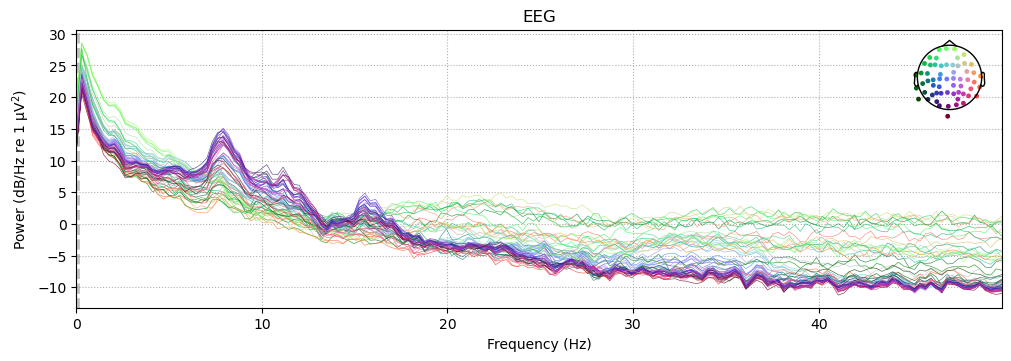

In [7]:
# Brain waves frequency spectrum (Power Spectral Density) plotting
raw_fresh.compute_psd(fmax=50).plot()
plt.show()
